# ---------------------------------------------------------
# Section 0: Data Cleaning and Feature Selection
# Objective:
#   - Clean raw survey responses
#   - Select validated TPACK dimensions
# Note:
#   All TPACK dimensions, including MTPACK,
#   were directly measured in the instrument.
# ---------------------------------------------------------


In [ ]:
df = pd.read_csv(
    r"data\tpack_Data.csv",
    encoding="latin1"
)

In [12]:
df.dtypes

TK1     int64
TK2     int64
TK3     int64
CK1     int64
CK2     int64
CK3     int64
CK4     int64
PK1     int64
PK2     int64
PK3     int64
PK4     int64
PK5     int64
PK6     int64
PCK1    int64
PCK2    int64
PCK3    int64
PCK4    int64
PCK5    int64
TCK1    int64
TCK2    int64
TCK3    int64
TCK4    int64
TPK1    int64
TPK2    int64
TPK3    int64
TPK4    int64
dtype: object

In [13]:
df.isnull().sum()

TK1     0
TK2     0
TK3     0
CK1     0
CK2     0
CK3     0
CK4     0
PK1     0
PK2     0
PK3     0
PK4     0
PK5     0
PK6     0
PCK1    0
PCK2    0
PCK3    0
PCK4    0
PCK5    0
TCK1    0
TCK2    0
TCK3    0
TCK4    0
TPK1    0
TPK2    0
TPK3    0
TPK4    0
dtype: int64

In [14]:
df = df.fillna(df.mean())

In [15]:
df.describe()

,TK1,TK2,TK3,CK1,CK2,CK3,CK4,PK1,PK2,PK3,...,PCK4,PCK5,TCK1,TCK2,TCK3,TCK4,TPK1,TPK2,TPK3,TPK4
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,...,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,2.630363,2.564356,2.768977,2.627063,2.590759,2.557756,2.415842,2.699670,2.551155,2.726073,...,2.663366,2.594059,2.594059,2.623762,2.547855,2.557756,2.580858,2.650165,2.564356,2.429043
std,0.691961,0.667344,0.591967,0.668244,0.584723,0.642685,0.613329,0.675175,0.616971,0.733006,...,0.568673,0.543076,0.606448,0.673797,0.606412,0.667950,0.634987,0.595005,0.672287,0.695835
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,...,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,...,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
50%,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,2.000000,3.000000,3.000000,3.000000,...,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,2.000000
75%,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,...,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000
max,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,...,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000


In [16]:
TK_items = ["TK1", "TK2", "TK3"]

CK_items = ["CK1", "CK2", "CK3", "CK4"]

PK_items = ["PK1", "PK2", "PK3", "PK4", "PK5", "PK6"]

PCK_items = ["PCK1", "PCK2", "PCK3", "PCK4", "PCK5"]

TCK_items = ["TCK1", "TCK2", "TCK3", "TCK4"]

TPK_items = ["TPK1", "TPK2", "TPK3", "TPK4"]


In [17]:
df["TK"] = df[TK_items].mean(axis=1)
df["CK"] = df[CK_items].mean(axis=1)
df["PK"] = df[PK_items].mean(axis=1)
df["PCK"] = df[PCK_items].mean(axis=1)
df["TCK"] = df[TCK_items].mean(axis=1)
df["TPK"] = df[TPK_items].mean(axis=1)

In [18]:
tpack_profiles = df[[
    "TK",
    "CK",
    "PK",
    "PCK",
    "TCK",
    "TPK"
]]


In [19]:
tpack_profiles.head()

,TK,CK,PK,PCK,TCK,TPK
0,2.666667,2.25,2.000000,1.4,2.75,2.25
1,2.666667,2.00,2.000000,2.2,2.00,1.50
2,2.000000,2.50,1.500000,1.8,1.75,1.75
3,2.000000,2.50,1.666667,2.4,3.00,2.75
4,3.333333,3.00,2.166667,2.6,2.00,2.25


In [20]:
tpack_profiles.shape

(303, 6)

In [21]:
tpack_profiles.describe()

,TK,CK,PK,PCK,TCK,TPK
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,2.654565,2.547855,2.603960,2.585479,2.580858,2.556106
std,0.519169,0.516871,0.543636,0.503024,0.544825,0.514834
min,1.666667,1.000000,1.166667,1.200000,1.000000,1.000000
25%,2.333333,2.250000,2.166667,2.000000,2.125000,2.000000
50%,2.666667,2.500000,2.666667,2.800000,2.750000,2.500000
75%,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000
max,4.000000,4.000000,4.000000,3.800000,3.500000,4.000000


# ---------------------------------------------------------
# Section 1: Instrument Reliability Analysis
# Objective: Validate internal consistency of TPACK dimensions
# Method: Cronbach's Alpha
# Interpretation: α > 0.7 indicates acceptable reliability
# ---------------------------------------------------------


In [22]:
def cronback_alpha(df_items):
    df_items = df_items.dropna(axis=0)
    k = df_items.shape[1]
    variences = df_items.var(axis=0, ddof=1)
    total_var = df_items.sum(axis=1).var(ddof=1)
    return(k / (k-1)) * (1 - variences.sum() / total_var)

In [23]:
alpha_results = {
    "TK" : cronback_alpha(df[TK_items]),
    "CK" : cronback_alpha(df[CK_items]),
    "PK" : cronback_alpha(df[PK_items]),
    "PCK" : cronback_alpha(df[PCK_items]),
    "TCK" : cronback_alpha(df[TCK_items]),
    "TPK" : cronback_alpha(df[TPK_items])
}

alpha_results

{'TK': np.float64(0.7118678427591923),
 'CK': np.float64(0.841215381285228),
 'PK': np.float64(0.8643280620231476),
 'PCK': np.float64(0.9233836973872422),
 'TCK': np.float64(0.8741338659377105),
 'TPK': np.float64(0.800926307688079)}

In [24]:
descriptives = tpack_profiles.describe().T
descriptives

,count,mean,std,min,25%,50%,75%,max
TK,303.0,2.654565,0.519169,1.666667,2.333333,2.666667,3.0,4.0
CK,303.0,2.547855,0.516871,1.000000,2.250000,2.500000,3.0,4.0
PK,303.0,2.603960,0.543636,1.166667,2.166667,2.666667,3.0,4.0
PCK,303.0,2.585479,0.503024,1.200000,2.000000,2.800000,3.0,3.8
TCK,303.0,2.580858,0.544825,1.000000,2.125000,2.750000,3.0,3.5
TPK,303.0,2.556106,0.514834,1.000000,2.000000,2.500000,3.0,4.0


In [25]:
descriptives_paper = descriptives[["mean","std","min","max"]]
descriptives_paper = descriptives_paper.round(2)
descriptives_paper

,mean,std,min,max
TK,2.65,0.52,1.67,4.0
CK,2.55,0.52,1.00,4.0
PK,2.60,0.54,1.17,4.0
PCK,2.59,0.50,1.20,3.8
TCK,2.58,0.54,1.00,3.5
TPK,2.56,0.51,1.00,4.0


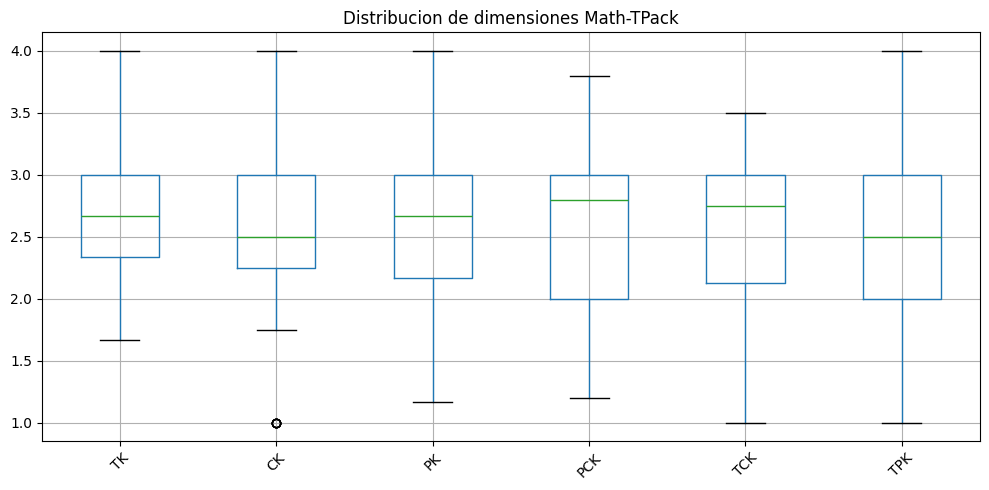

In [27]:
import matplotlib.pyplot as plt

tpack_profiles.boxplot(figsize=(10,5))
plt.xticks(rotation=45)
plt.title("Distribucion de dimensiones Math-TPack")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Section 3: Data Standardization
# Method: Z-score normalization
# Formula: Z = (X - μ) / σ
# Purpose:
#   Ensure all TPACK dimensions contribute equally
#   to Euclidean distance calculations used in clustering
# ---------------------------------------------------------


In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(tpack_profiles)

X_scaled[:5]


array([[ 0.02334736, -0.57721815, -1.11280304, -2.36060087,  0.31096535,
        -0.59555549],
       [ 0.02334736, -1.06169764, -1.11280304, -0.76758959, -1.06790052,
        -2.0547467 ],
       [-1.26287975, -0.09273865, -2.03405801, -1.56409523, -1.52752247,
        -1.56834963],
       [-1.26287975, -0.09273865, -1.72697302, -0.36933677,  0.7705873 ,
         0.37723865],
       [ 1.30957446,  0.87622034, -0.80571805,  0.02891605, -1.06790052,
        -0.59555549]])

# ---------------------------------------------------------
# Section 4: Determination of Optimal Number of Clusters
# Objective:
#   Evaluate internal clustering quality for different k
# Metrics:
#   - Silhouette Score (higher is better)
#   - Davies-Bouldin Index (lower is better)
#   - Calinski-Harabasz Index (higher is better)
# Purpose:
#   Identify macro-structure in teacher TPACK space
# ---------------------------------------------------------


Validación múltiple del número óptimo de clusters

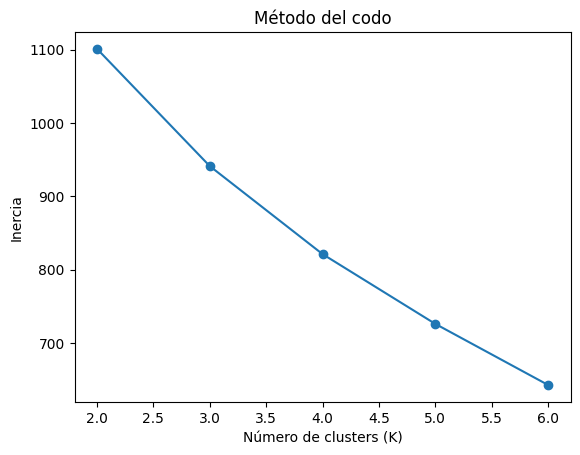

In [30]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

K_range = range(2, 7)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(K_range, inertia, marker='o')
plt.xlabel("Número de clusters (K)")
plt.ylabel("Inercia")
plt.title("Método del codo")
plt.show()


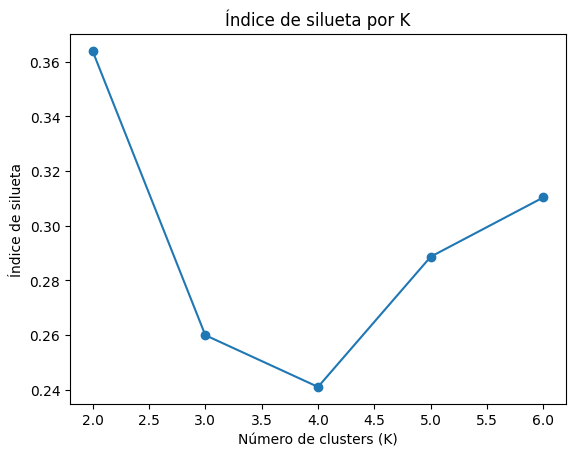

In [31]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

plt.plot(K_range, silhouette_scores, marker='o')
plt.xlabel("Número de clusters (K)")
plt.ylabel("Índice de silueta")
plt.title("Índice de silueta por K")
plt.show()


In [32]:
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import calinski_harabasz_score

K_range = range(2, 8)

results = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = kmeans.fit_predict(X_scaled)

    sil = silhouette_score(X_scaled, labels)
    db = davies_bouldin_score(X_scaled, labels)
    ch = calinski_harabasz_score(X_scaled, labels)

    results.append((k, sil, db, ch))

for r in results:
    print(f"k={r[0]} | Silhouette={r[1]:.3f} | DBI={r[2]:.3f} | CH={r[3]:.2f}")


k=2 | Silhouette=0.364 | DBI=1.103 | CH=196.11
k=3 | Silhouette=0.260 | DBI=1.518 | CH=139.79
k=4 | Silhouette=0.241 | DBI=1.501 | CH=121.00
k=5 | Silhouette=0.289 | DBI=1.352 | CH=112.05
k=6 | Silhouette=0.309 | DBI=1.229 | CH=110.02
k=7 | Silhouette=0.331 | DBI=0.965 | CH=104.52


In [33]:
# Comparación formal KMeans vs Jerárquico
# Análisis objetivo de tus métricas (Ward)
from scipy.cluster.hierarchy import linkage, fcluster

for k in K_range:
    Z = linkage(X_scaled, method='ward')
    labels = fcluster(Z, k, criterion='maxclust')

    sil = silhouette_score(X_scaled, labels)
    db = davies_bouldin_score(X_scaled, labels)
    ch = calinski_harabasz_score(X_scaled, labels)

    print(f"Ward k={k} | Sil={sil:.3f} | DBI={db:.3f} | CH={ch:.2f}")


Ward k=2 | Sil=0.363 | DBI=1.103 | CH=192.25
Ward k=3 | Sil=0.256 | DBI=1.495 | CH=139.28
Ward k=4 | Sil=0.249 | DBI=1.475 | CH=118.28
Ward k=5 | Sil=0.278 | DBI=1.333 | CH=109.69
Ward k=6 | Sil=0.304 | DBI=1.171 | CH=108.06
Ward k=7 | Sil=0.305 | DBI=1.197 | CH=106.33


In [70]:
#Validación estadística entre clusters
#anova
from scipy.stats import f_oneway

for col in tpack_profiles.columns[:-1]:  # sin la columna cluster
    groups = [tpack_profiles[tpack_profiles['Cluster'] == c][col] 
              for c in tpack_profiles['Cluster'].unique()]
    
    f_stat, p_value = f_oneway(*groups)
    
    print(f"{col}: p-value = {p_value:.5f}")


TK: p-value = 0.00000
CK: p-value = 0.00000
PK: p-value = 0.00000
PCK: p-value = 0.00000
TCK: p-value = 0.00000
TPK: p-value = 0.00000


In [71]:
#Interpretabilidad mejorada
cluster_means = tpack_profiles.groupby("Cluster").mean()
global_mean = tpack_profiles.mean()

cluster_diff = cluster_means - global_mean
print(cluster_diff)


               CK  Cluster       PCK        PK       TCK        TK       TPK
Cluster                                                                     
0        0.478616      NaN  0.442757  0.537216  0.363260  0.459160  0.373306
1       -0.426531      NaN -0.641361 -0.562294 -0.525711 -0.492801 -0.570811
2       -0.096874      NaN  0.026286 -0.099058  0.306397  0.201644  0.193894
3       -0.037438      NaN  0.068688  0.055762 -0.549608 -0.543454 -0.264439


In [72]:
tpack_profiles['Cluster'].value_counts()


Cluster
2    102
0     85
1     68
3     48
Name: count, dtype: int64

# ---------------------------------------------------------
# Section 5: K-Means Clustering
# Objective:
#   Segment teachers into latent profiles
# Optimization:
#   Minimize within-cluster variance
# Parameters:
#   n_clusters = 4
#   random_state = 42 (reproducibility)
#   n_init = 20 (stability)
# Output:
#   Cluster labels and centroids
# ---------------------------------------------------------


In [45]:
from scipy.cluster.hierarchy import linkage, dendrogram

Z = linkage(X_scaled, method="ward")


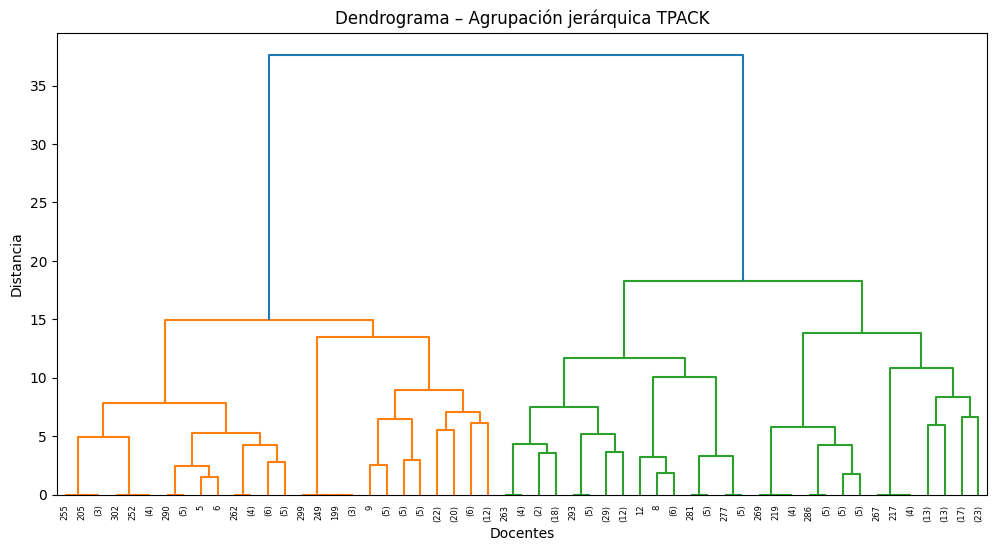

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
dendrogram(
    Z,
    truncate_mode="level",
    p=5
)
plt.title("Dendrograma – Agrupación jerárquica TPACK")
plt.xlabel("Docentes")
plt.ylabel("Distancia")
plt.show()


In [38]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)


In [39]:
tpack_profiles["Cluster"] = clusters
tpack_profiles.head()


C:\Users\josel\AppData\Local\Temp\ipykernel_19144\800187564.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tpack_profiles["Cluster"] = clusters


,TK,CK,PK,PCK,TCK,TPK,Cluster
0,2.666667,2.25,2.000000,1.4,2.75,2.25,1
1,2.666667,2.00,2.000000,2.2,2.00,1.50,1
2,2.000000,2.50,1.500000,1.8,1.75,1.75,1
3,2.000000,2.50,1.666667,2.4,3.00,2.75,2
4,3.333333,3.00,2.166667,2.6,2.00,2.25,2


In [40]:
tpack_profiles["Cluster"].value_counts()


Cluster
2    102
0     85
1     68
3     48
Name: count, dtype: int64

In [41]:
centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=tpack_profiles.columns[:-1]
)

centroids

,TK,CK,PK,PCK,TCK,TPK
0,3.113725,3.026471,3.141176,3.028235,2.944118,2.929412
1,2.161765,2.121324,2.041667,1.944118,2.055147,1.985294
2,2.856209,2.450980,2.504902,2.611765,2.887255,2.750000
3,2.111111,2.510417,2.659722,2.654167,2.031250,2.291667


In [43]:
features = [
    "TK", "CK", "PK",
    "TPK", "TCK", "PCK"
]
X = df[features]


In [47]:
from scipy.cluster.hierarchy import fcluster

df["cluster"] = fcluster(Z, t=4, criterion="maxclust")


In [48]:
profile_summary = (
    df
    .groupby("cluster")[features]
    .mean()
)

profile_summary


,TK,CK,PK,TPK,TCK,PCK
cluster,,,,,,
1,2.085714,2.557143,2.580952,2.178571,2.085714,2.885714
2,2.170732,2.164634,2.170732,2.088415,2.030488,1.970732
3,3.108696,3.008152,3.110507,2.910326,2.888587,3.008696
4,2.843972,2.428191,2.494681,2.757979,2.944149,2.595745


In [50]:
class TPACKRecommender:
    
    def __init__(self, dataset_path):
        self.apps = pd.read_csv(dataset_path)
        self.app_vectors = self.apps[
            ["TK", "CK", "PK", "TPK", "TCK", "PCK"]
        ].values
        
    def recommend(self, docente_vector, top_n=5):
        
        docente_vector = np.array(docente_vector).reshape(1, -1)
        
        similarities = cosine_similarity(
            docente_vector,
            self.app_vectors
        )
        
        self.apps["similarity_score"] = similarities.flatten()
        
        ranked = self.apps.sort_values(
            "similarity_score",
            ascending=False
        )
        
        return ranked.head(top_n)


In [51]:
recommender = TPACKRecommender(
    "C:/Users/josel/OneDrive/Documentos/udla/edtech_tpack_recommender.csv"
)


In [52]:
docente = [0.71, 0.84, 0.92, 0.80, 0.87, 0.92]


In [53]:
recommender.recommend(docente, top_n=5)


,app_id,title,TK,CK,PK,TPK,TCK,PCK,final_score,similarity_score
19,19,Pluralsight – The Technology Skills Platform,0.586336,0.659656,0.752040,0.635709,0.622996,0.705848,0.663140,0.998934
52,52,Smaterr Learning App,0.413292,0.539642,0.562865,0.399228,0.476467,0.551253,0.493379,0.996975
39,39,Edukoya - Learning App (beta),0.476505,0.539642,0.634138,0.415149,0.508073,0.586890,0.531170,0.996041
20,20,upGrad - Online Learning Courses,0.573377,0.730604,0.738318,0.508285,0.651990,0.734461,0.660071,0.996024
26,26,10 Minute School - Online Learning Courses,0.566031,0.819734,0.741782,0.582120,0.692882,0.780758,0.699229,0.995976


In [54]:
docente_c = [
    0.90,  # TK  (muy alto)
    0.88,  # CK  (alto)
    0.60,  # PK  (medio)
    0.70,  # TPK
    0.81,  # TCK
    0.51   # PCK
]

In [55]:
recommender.recommend(docente_c, top_n=5)


,app_id,title,TK,CK,PK,TPK,TCK,PCK,final_score,similarity_score
68,68,Teams By Lurningo,0.524975,0.381666,0.451678,0.353103,0.453321,0.416672,0.432462,0.980051
34,34,Wondrium - Learning & Courses,0.612504,0.538569,0.602902,0.580945,0.575536,0.570735,0.581101,0.979731
19,19,Pluralsight – The Technology Skills Platform,0.586336,0.659656,0.752040,0.635709,0.622996,0.705848,0.663140,0.965574
26,26,10 Minute School - Online Learning Courses,0.566031,0.819734,0.741782,0.582120,0.692882,0.780758,0.699229,0.964377
20,20,upGrad - Online Learning Courses,0.573377,0.730604,0.738318,0.508285,0.651990,0.734461,0.660071,0.963498


Metricas de medicion

1 Structural Alignment Index (SAI)

In [56]:
from sklearn.metrics.pairwise import cosine_similarity

top5 = recommender.recommend(docente, top_n=5)
coherencia = top5[["TK","CK","PK","TPK","TCK","PCK"]].mean()


cosine_similarity(
    np.array(docente).reshape(1,-1),
    coherencia.values.reshape(1,-1)
)


array([[0.99787373]])

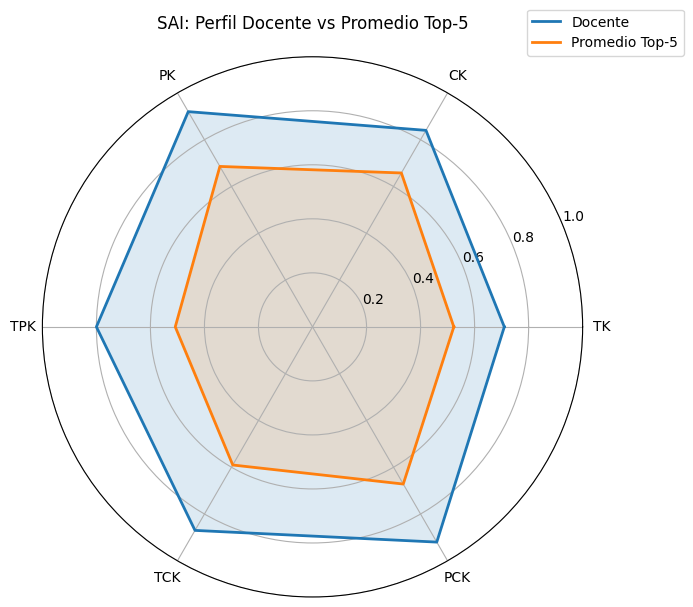

In [57]:
import numpy as np
import matplotlib.pyplot as plt

# 1) Etiquetas y datos
labels = ["TK", "CK", "PK", "TPK", "TCK", "PCK"]

docente_vec = np.array(docente, dtype=float)

coherencia = top5[labels].mean().values.astype(float)  # promedio top-5

# 2) Preparar ángulos para radar
angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]  # cerrar el círculo

docente_plot = np.concatenate([docente_vec, [docente_vec[0]]])
coherencia_plot = np.concatenate([coherencia, [coherencia[0]]])

# 3) Dibujar radar
fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

ax.plot(angles, docente_plot, linewidth=2, label="Docente")
ax.fill(angles, docente_plot, alpha=0.15)

ax.plot(angles, coherencia_plot, linewidth=2, label="Promedio Top-5")
ax.fill(angles, coherencia_plot, alpha=0.15)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)

ax.set_ylim(0, 1)
ax.set_title("SAI: Perfil Docente vs Promedio Top-5", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.2, 1.1))

plt.tight_layout()
plt.show()

# 4) (Opcional) Guardar imagen para el paper
# plt.savefig("SAI_radar.png", dpi=300, bbox_inches="tight")


Sensibilidad

In [58]:
docente_variado = [0.80, 0.88, 0.60, 0.70, 0.89, 0.65]

top5_variado = recommender.recommend(docente_variado, top_n=5)

set(top5["app_id"]) & set(top5_variado["app_id"])


{19, 20, 26}

In [59]:
rsc = len(set(top5["app_id"]) & set(top5_variado["app_id"])) / 5
print("Ranking Stability Coefficient:", rsc)


Ranking Stability Coefficient: 0.6


Ranking Stability Coefficient: 0.6


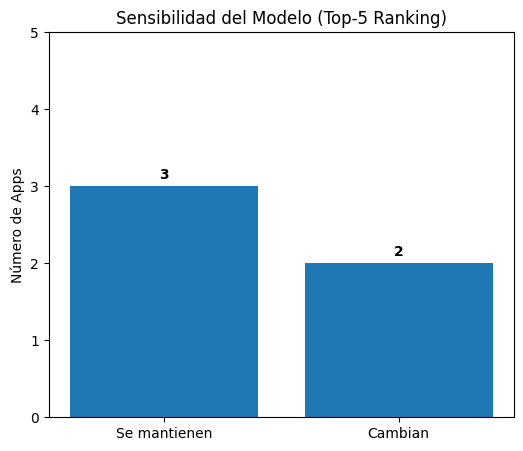

In [60]:
import matplotlib.pyplot as plt

# Total recomendado
total = 5

# Intersección (ya la calculaste)
interseccion = len(set(top5["app_id"]) & set(top5_variado["app_id"]))

cambiaron = total - interseccion

# Datos
labels = ["Se mantienen", "Cambian"]
values = [interseccion, cambiaron]

# Gráfico
plt.figure(figsize=(6,5))
bars = plt.bar(labels, values)

plt.title("Sensibilidad del Modelo (Top-5 Ranking)")
plt.ylabel("Número de Apps")
plt.ylim(0,5)

for i, v in enumerate(values):
    plt.text(i, v + 0.1, str(v), ha='center', fontweight='bold')
rsc = interseccion / total
print("Ranking Stability Coefficient:", rsc)

plt.show()


Estabilidad Global del Sistema

In [62]:
similarity_means = []
all_recommended = []

for profile in synthetic_profiles:
    
    top = recommender.recommend(profile, top_n=5)
    
    similarity_means.append(
        top["similarity_score"].mean()
    )
    
    all_recommended.extend(
        top["app_id"].tolist()
    )


In [63]:
mean_similarity = np.mean(similarity_means)
std_similarity = np.std(similarity_means)

coverage = len(set(all_recommended)) / len(recommender.apps)

print("Mean Top-5 Similarity:", mean_similarity)
print("Std Top-5 Similarity:", std_similarity)
print("Catalog Coverage:", coverage)


Mean Top-5 Similarity: 0.9845594030228365
Std Top-5 Similarity: 0.010080032834663775
Catalog Coverage: 0.37037037037037035


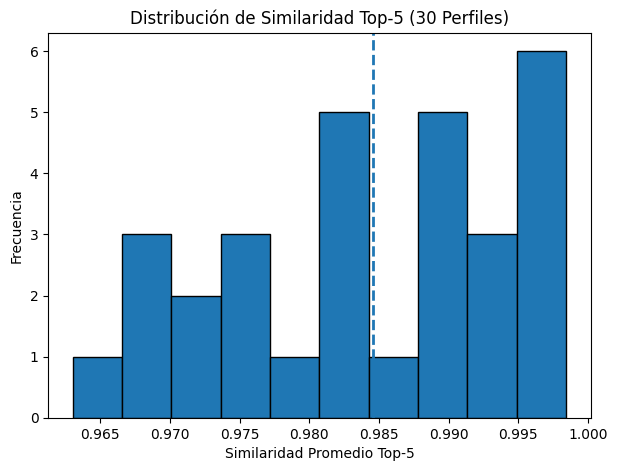

In [64]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.hist(similarity_means, bins=10, edgecolor='black')

plt.axvline(mean_similarity, linestyle='dashed', linewidth=2)
plt.title("Distribución de Similaridad Top-5 (30 Perfiles)")
plt.xlabel("Similaridad Promedio Top-5")
plt.ylabel("Frecuencia")

plt.show()


Dispersión del espacio TPACK

In [66]:
import numpy as np

dimension_variance = np.var(app_vectors, axis=0)

print("Variance per dimension:")
print(dimension_variance)


Variance per dimension:
[0.00983596 0.04928632 0.10277839 0.03696762 0.01252821 0.03911127]


In [67]:
global_variance = np.mean(dimension_variance)
print("Global Space Variance:", global_variance)


Global Space Variance: 0.041751295206914264


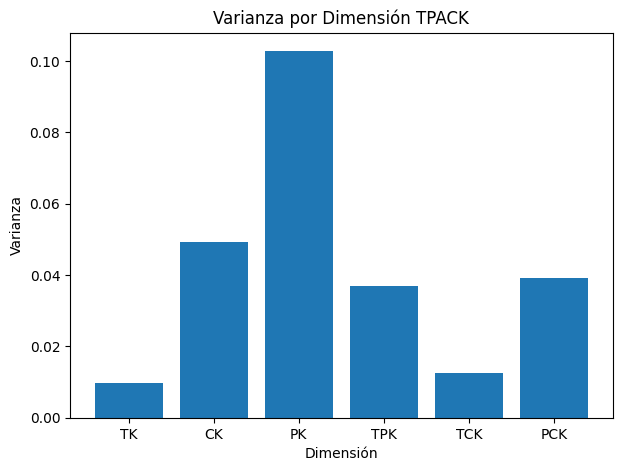

In [68]:
import matplotlib.pyplot as plt

labels = ["TK", "CK", "PK", "TPK", "TCK", "PCK"]

plt.figure(figsize=(7,5))

plt.bar(labels, dimension_variance)

plt.title("Varianza por Dimensión TPACK")
plt.ylabel("Varianza")
plt.xlabel("Dimensión")

plt.show()


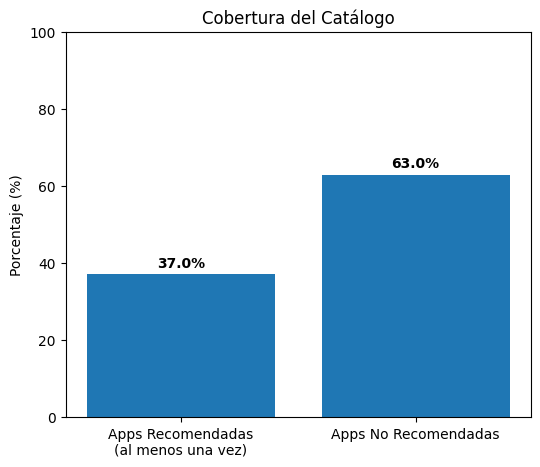

In [69]:
plt.figure(figsize=(6,5))

used = coverage * 100
unused = 100 - used

labels = ["Apps Recomendadas\n(al menos una vez)", "Apps No Recomendadas"]
values = [used, unused]

plt.bar(labels, values)

plt.title("Cobertura del Catálogo")
plt.ylabel("Porcentaje (%)")
plt.ylim(0,100)

for i, v in enumerate(values):
    plt.text(i, v + 2, f"{v:.1f}%", ha='center', fontweight='bold')

plt.show()
